# Students Depression Analysis

### **Introduction to Students Depression Analysis**  
The **Students Depression Analysis** project aims to identify and understand the factors affecting students' mental health using **Machine Learning (ML)**. Many students face stress due to academic pressure, social challenges, and personal issues, leading to depression. This project helps in early detection by analyzing data and predicting at-risk students. The insights can assist **students, teachers, parents, and mental health professionals** in providing timely support. By using data-driven methods, we can improve student well-being and academic performance.

#### **Why We Chose This Project?**  
Student depression is a growing concern in today’s fast-paced world. Academic pressure, social expectations, financial 
stress, and personal issues can lead to mental health problems among students. By using **Machine Learning (ML)**, we can 
analyze various factors contributing to student depression and help in early detection and prevention.  

#### **Purpose of the Project**  
The main goal of this project is to:  
- Identify students who may be at risk of depression.  
- Understand the key factors affecting student mental health.  
- Provide insights to educators, parents, and mental health professionals.  
- Develop an early warning system to help students get timely support.  

#### **Final Thoughts**  
This project is important because **mental health is just as important as physical health**. With ML, we can create tools 
that help students get the support they need at the right time. This can lead to **happier, healthier students and better 
academic performance**.

### 1. Import Libraries :

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder
from sklearn .preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings('ignore')

### 2.Read the data

In [5]:
df=pd.read_csv('Student Depression Dataset.csv')
df

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1
1,8,Female,24,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0
2,26,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0
3,30,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1
4,32,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27,Surat,Student,5,0,5.75,5,0,5-6 hours,Unhealthy,Class 12,Yes,7,1.0,Yes,0
27897,140686,Male,27,Ludhiana,Student,2,0,9.40,3,0,Less than 5 hours,Healthy,MSc,No,0,3.0,Yes,0
27898,140689,Male,31,Faridabad,Student,3,0,6.61,4,0,5-6 hours,Unhealthy,MD,No,12,2.0,No,0
27899,140690,Female,18,Ludhiana,Student,5,0,6.88,2,0,Less than 5 hours,Healthy,Class 12,Yes,10,5.0,No,1


## Exploratory Data Analysis (EDA)

### 1.Data Cleaning and Preprocessing

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  int64  
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  int64  
 6   Work Pressure                          27901 non-null  int64  
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  int64  
 9   Job Satisfaction                       27901 non-null  int64  
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [7]:
#Remove Duplicate rows
df.drop_duplicates(inplace=True)

In [8]:
#Data Type Correction
df.dtypes

id                                         int64
Gender                                    object
Age                                        int64
City                                      object
Profession                                object
Academic Pressure                          int64
Work Pressure                              int64
CGPA                                     float64
Study Satisfaction                         int64
Job Satisfaction                           int64
Sleep Duration                            object
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?     object
Work/Study Hours                           int64
Financial Stress                         float64
Family History of Mental Illness          object
Depression                                 int64
dtype: object

In [9]:
# Drop unnecessary columns
df = df.drop(columns=['id', 'City','Profession'])

In [10]:
df

,Gender,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1
1,Female,24,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0
2,Male,31,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0
3,Female,28,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1
4,Female,25,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,Female,27,5,0,5.75,5,0,5-6 hours,Unhealthy,Class 12,Yes,7,1.0,Yes,0
27897,Male,27,2,0,9.40,3,0,Less than 5 hours,Healthy,MSc,No,0,3.0,Yes,0
27898,Male,31,3,0,6.61,4,0,5-6 hours,Unhealthy,MD,No,12,2.0,No,0
27899,Female,18,5,0,6.88,2,0,Less than 5 hours,Healthy,Class 12,Yes,10,5.0,No,1


##### Here I want to convert Sleep Duration in numbers. Therefore

In [11]:
print(df['Sleep Duration'].unique())

['5-6 hours' 'Less than 5 hours' '7-8 hours' 'More than 8 hours' 'Others']


In [12]:
# Define the mapping dictionary
sleep_duration_mapping = {
    'Less than 5 hours': 4,
    '5-6 hours': 5,
    '7-8 hours': 7,
    'More than 8 hours': 8
}

# Apply the mapping
df['Sleep Duration'] = df['Sleep Duration'].map(sleep_duration_mapping)

In [13]:
#Check the conversion
print(df['Sleep Duration'].head())
print(df['Sleep Duration'].dtype)

0    5.0
1    5.0
2    4.0
3    7.0
4    5.0
Name: Sleep Duration, dtype: float64
float64


In [14]:
#To check missing values 
df.isnull().sum()

Gender                                    0
Age                                       0
Academic Pressure                         0
Work Pressure                             0
CGPA                                      0
Study Satisfaction                        0
Job Satisfaction                          0
Sleep Duration                           18
Dietary Habits                            0
Degree                                    0
Have you ever had suicidal thoughts ?     0
Work/Study Hours                          0
Financial Stress                          3
Family History of Mental Illness          0
Depression                                0
dtype: int64

In [15]:
# Handle Missing Data
df.dropna(inplace=True)

In [16]:
print(df['Sleep Duration'].dtype)

float64


### 2.Finding Outliers

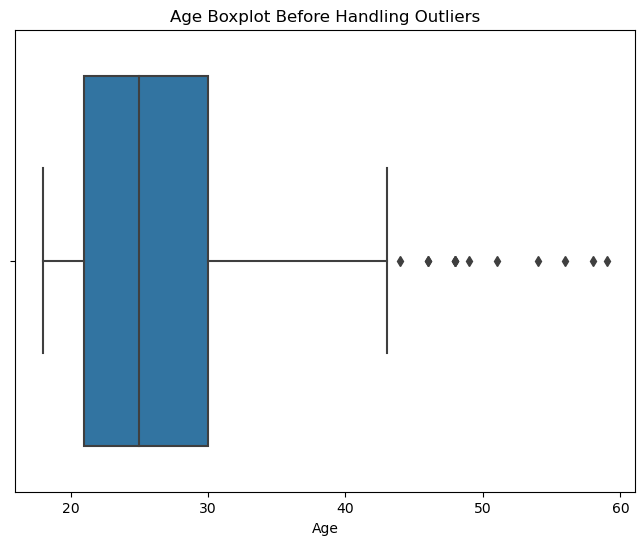

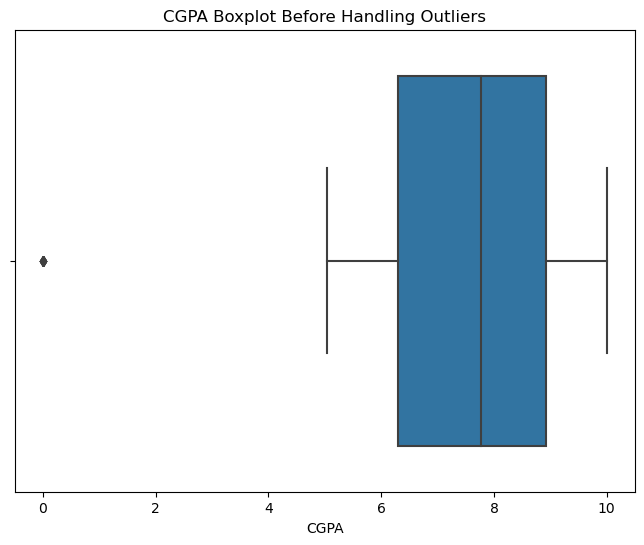

In [17]:
# Boxplot for Age
plt.figure(figsize=(8, 6))
sns.boxplot(df['Age'])
plt.title('Age Boxplot Before Handling Outliers')
plt.show()

# Boxplot for CGPA
plt.figure(figsize=(8, 6))
sns.boxplot(df['CGPA'])
plt.title('CGPA Boxplot Before Handling Outliers')
plt.show()

In [18]:
#Identify Outliers Using IQR Method

def calculate_iqr_bounds(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# Calculate IQR bounds for Age and CGPA
age_lower, age_upper = calculate_iqr_bounds(df['Age'])
cgpa_lower, cgpa_upper = calculate_iqr_bounds(df['CGPA'])

print(f'Age Outlier Range: Below {age_lower} or Above {age_upper}')
print(f'CGPA Outlier Range: Below {cgpa_lower} or Above {cgpa_upper}')


Age Outlier Range: Below 7.5 or Above 43.5
CGPA Outlier Range: Below 2.345 or Above 12.865


In [19]:
# Remove outliers

# Remove outliers
filtered_df = df[
    (df['Age'] >= age_lower) & (df['Age'] <= age_upper) &
    (df['CGPA'] >= cgpa_lower) & (df['CGPA'] <= cgpa_upper)
]

print(f'Original Data Shape: {df.shape}')
print(f'Filtered Data Shape: {filtered_df.shape}')

Original Data Shape: (27880, 15)
Filtered Data Shape: (27859, 15)


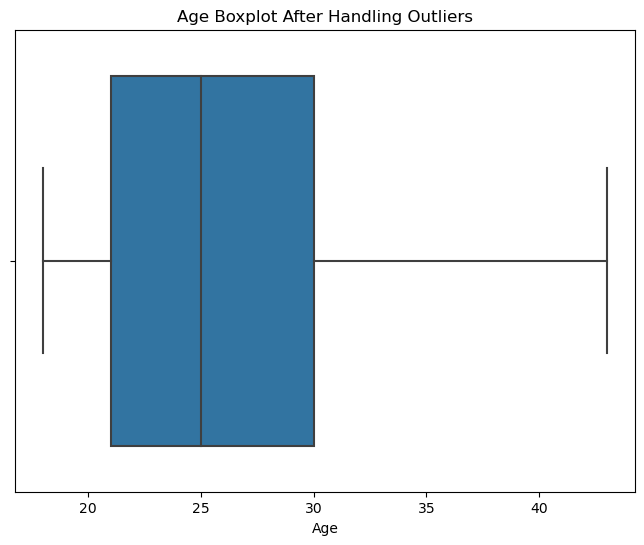

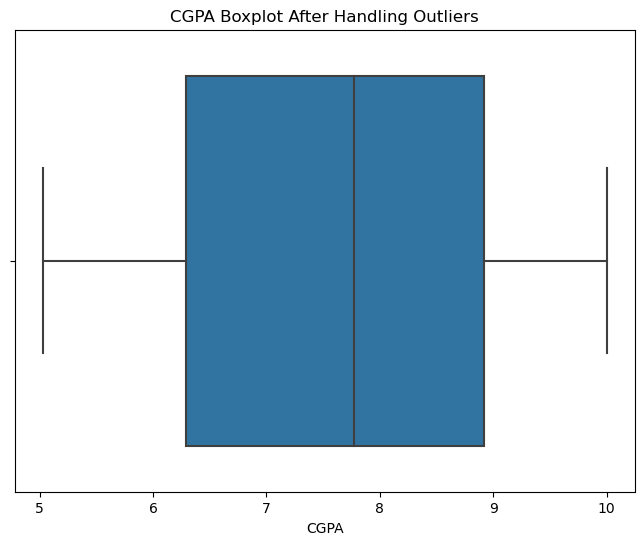

In [20]:
# Boxplot for Age After Removing Outliers
plt.figure(figsize=(8, 6))
sns.boxplot(filtered_df['Age'])
plt.title('Age Boxplot After Handling Outliers')
plt.show()

# Boxplot for CGPA After Removing Outliers
plt.figure(figsize=(8, 6))
sns.boxplot(filtered_df['CGPA'])
plt.title('CGPA Boxplot After Handling Outliers')
plt.show()

### Conclusion :
Outliers in the `Age` and `CGPA` columns were identified and removed using the IQR technique. The original dataset had 27,898 rows, and after filtering, 39 rows were removed, leaving 27,859 rows. This cleaning process ensures more accurate model performance by eliminating extreme values that could skew results. The dataset is now ready for further analysis and modeling.

### 3.Separation of features and target :


##### Here Target is Depression and other all columns are Features.

In [21]:
#Separation of features and target :
feature=filtered_df.iloc[:,:-1]
target=filtered_df['Depression']

In [22]:
feature

,Gender,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,Male,33,5,0,8.97,2,0,5.0,Healthy,B.Pharm,Yes,3,1.0,No
1,Female,24,2,0,5.90,5,0,5.0,Moderate,BSc,No,3,2.0,Yes
2,Male,31,3,0,7.03,5,0,4.0,Healthy,BA,No,9,1.0,Yes
3,Female,28,3,0,5.59,2,0,7.0,Moderate,BCA,Yes,4,5.0,Yes
4,Female,25,4,0,8.13,3,0,5.0,Moderate,M.Tech,Yes,1,1.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,Female,27,5,0,5.75,5,0,5.0,Unhealthy,Class 12,Yes,7,1.0,Yes
27897,Male,27,2,0,9.40,3,0,4.0,Healthy,MSc,No,0,3.0,Yes
27898,Male,31,3,0,6.61,4,0,5.0,Unhealthy,MD,No,12,2.0,No
27899,Female,18,5,0,6.88,2,0,4.0,Healthy,Class 12,Yes,10,5.0,No


In [23]:
target

0        1
1        0
2        0
3        1
4        0
        ..
27896    0
27897    0
27898    0
27899    1
27900    1
Name: Depression, Length: 27859, dtype: int64

### 4.To check for skewness

In [24]:
feature.describe()

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Work/Study Hours,Financial Stress
count,27859.000000,27859.000000,27859.0,27859.000000,27859.000000,27859.000000,27859.000000,27859.000000,27859.000000
mean,25.810510,3.142288,0.0,7.658723,2.944506,0.000179,5.879464,7.157543,3.139775
std,4.877959,1.381056,0.0,1.464545,1.360397,0.021601,1.590626,3.706860,1.437447
min,18.000000,0.000000,0.0,5.030000,0.000000,0.000000,4.000000,0.000000,1.000000
25%,21.000000,2.000000,0.0,6.290000,2.000000,0.000000,4.000000,4.000000,2.000000
50%,25.000000,3.000000,0.0,7.770000,3.000000,0.000000,5.000000,8.000000,3.000000
75%,30.000000,4.000000,0.0,8.920000,4.000000,0.000000,7.000000,10.000000,4.000000
max,43.000000,5.000000,0.0,10.000000,5.000000,3.000000,8.000000,12.000000,5.000000


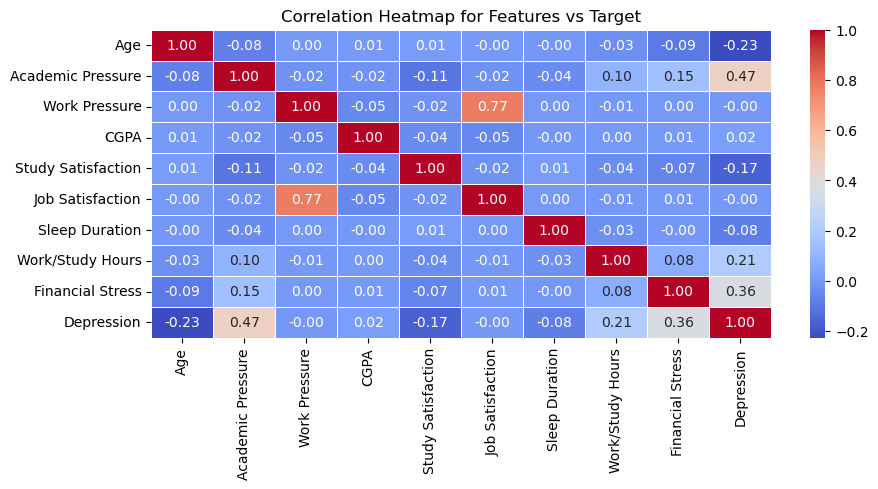

In [25]:
#6.Create a heat map 

plt.figure(figsize=(10,4))
correlation_matrix=df.corr()
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)

#Customize the plot
plt.title('Correlation Heatmap for Features vs Target')
plt.show()

#####  By taking statistical description, Compare the mean and median to check skewness . Then here observed that features are normally distributed.

In [26]:
#Numerical Columns :
col=feature.select_dtypes(['int64','float64']).columns
col

Index(['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
       'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration',
       'Work/Study Hours', 'Financial Stress'],
      dtype='object')

Age
0.07836021963689255


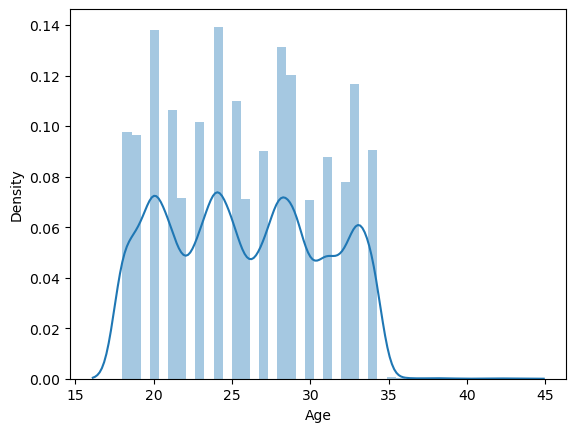

Academic Pressure
-0.1346589366775221


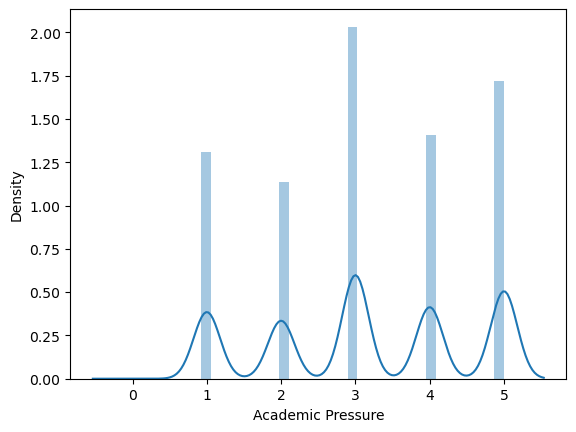

Work Pressure
nan


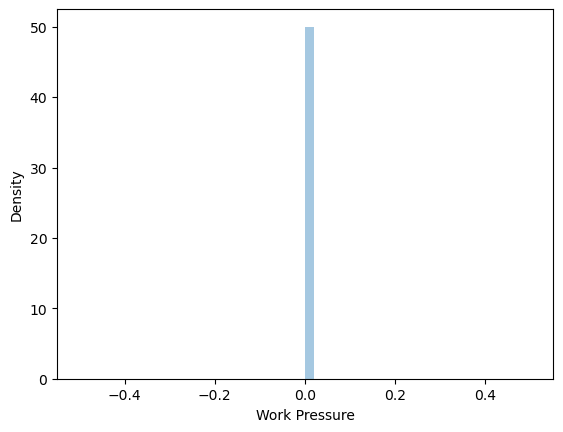

CGPA
-0.07363507576614357


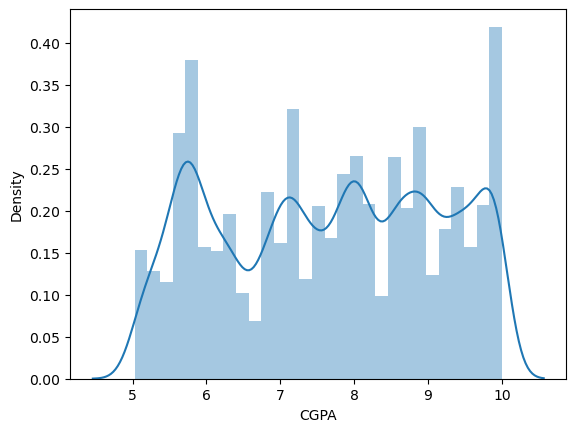

Study Satisfaction
0.01160466748838256


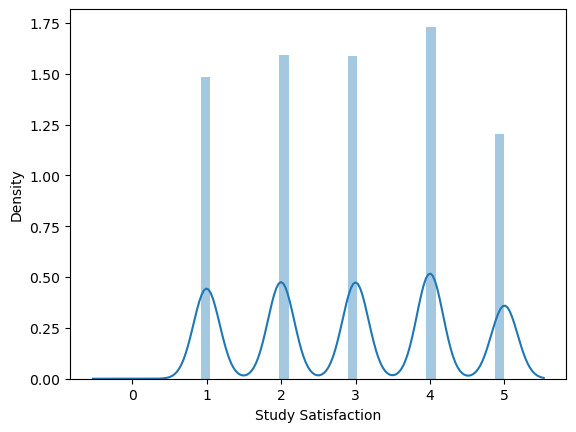

Job Satisfaction
124.62176265681171


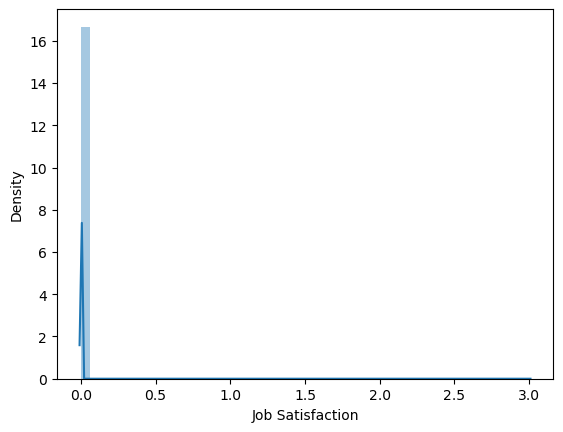

Sleep Duration
0.07681709031678256


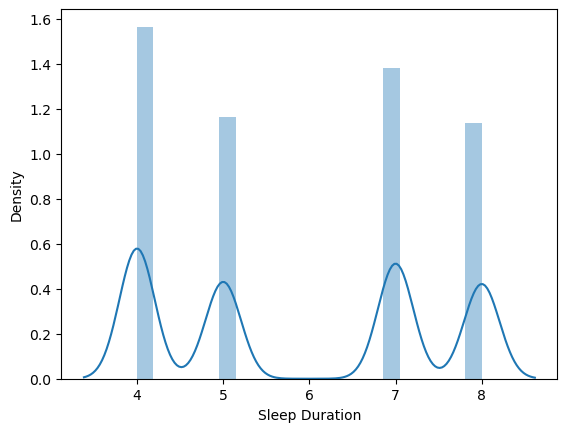

Work/Study Hours
-0.4552987520270994


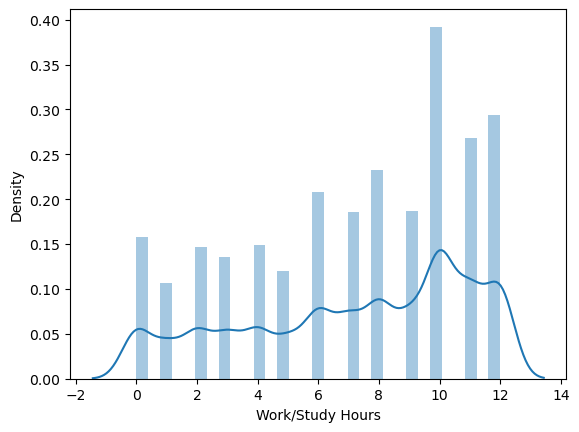

Financial Stress
-0.13020471058210975


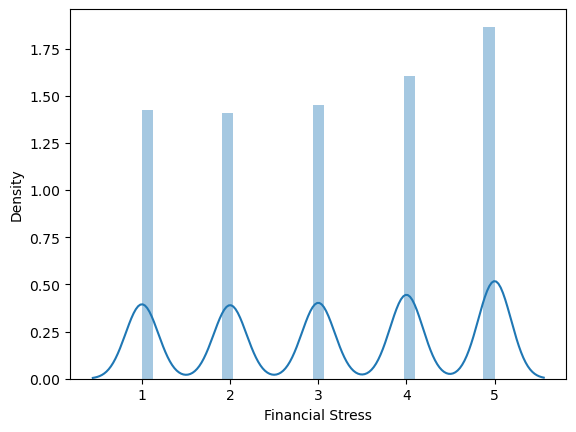

In [27]:
#To know amount of skewness :
from scipy.stats import skew   #scipy :scientific python library

for i in feature[col]:
    print(i)
    print(skew(feature[i]))
    
    plt.figure()
    sns.distplot(feature[i])
    plt.show()

In [28]:
from sklearn.preprocessing import PowerTransformer

#Apply Yeo-Johnson transformation
pt=PowerTransformer(method='yeo-johnson',standardize=False)
df['Work/Study Hours']=pt.fit_transform(df[['Work/Study Hours']])

#check new skewness:
new_skewness=skew(df["Work/Study Hours"])
print(f'new_skewness after transformation:{new_skewness:.4f}')

new_skewness after transformation:-0.3680


### 5.Encoding : Handling Categorical Data

##### To handle multiple categorical column Ordinal Encoding is used.

In [29]:
oe=OrdinalEncoder()

In [30]:
cat_col=feature.select_dtypes(object).columns
cat_col

Index(['Gender', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?',
       'Family History of Mental Illness'],
      dtype='object')

In [31]:
feature[cat_col]

,Gender,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Family History of Mental Illness
0,Male,Healthy,B.Pharm,Yes,No
1,Female,Moderate,BSc,No,Yes
2,Male,Healthy,BA,No,Yes
3,Female,Moderate,BCA,Yes,Yes
4,Female,Moderate,M.Tech,Yes,No
...,...,...,...,...,...
27896,Female,Unhealthy,Class 12,Yes,Yes
27897,Male,Healthy,MSc,No,Yes
27898,Male,Unhealthy,MD,No,No
27899,Female,Healthy,Class 12,Yes,No


In [32]:
feature[cat_col]=oe.fit_transform(feature[cat_col])

In [33]:
feature

,Gender,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,1.0,33,5,0,8.97,2,0,5.0,0.0,3.0,1.0,3,1.0,0.0
1,0.0,24,2,0,5.90,5,0,5.0,1.0,10.0,0.0,3,2.0,1.0
2,1.0,31,3,0,7.03,5,0,4.0,0.0,5.0,0.0,9,1.0,1.0
3,0.0,28,3,0,5.59,2,0,7.0,1.0,7.0,1.0,4,5.0,1.0
4,0.0,25,4,0,8.13,3,0,5.0,1.0,17.0,1.0,1,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,0.0,27,5,0,5.75,5,0,5.0,3.0,11.0,1.0,7,1.0,1.0
27897,1.0,27,2,0,9.40,3,0,4.0,0.0,25.0,0.0,0,3.0,1.0
27898,1.0,31,3,0,6.61,4,0,5.0,3.0,22.0,0.0,12,2.0,0.0
27899,0.0,18,5,0,6.88,2,0,4.0,0.0,11.0,1.0,10,5.0,0.0


### 6.Scaling

In [34]:
sc=StandardScaler()
feature.iloc[:,:]=sc.fit_transform(feature.iloc[:,:])

In [35]:
x=feature
y=target

In [36]:
x

,Gender,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,0.891195,1.473899,1.345163,0.0,0.895364,-0.694300,-0.008309,-0.552915,-1.182209,-1.093835,0.761476,-1.121601,-1.488621,-0.968443
1,-1.122088,-0.371168,-0.827127,0.0,-1.200888,1.510979,-0.008309,-0.552915,-0.375528,-0.126258,-1.313239,-1.121601,-0.792931,1.032585
2,0.891195,1.063884,-0.103030,0.0,-0.429304,1.510979,-0.008309,-1.181609,-1.182209,-0.817384,-1.313239,0.497049,-1.488621,1.032585
3,-1.122088,0.448862,-0.103030,0.0,-1.412562,-0.694300,-0.008309,0.704475,-0.375528,-0.540934,0.761476,-0.851826,1.294140,1.032585
4,-1.122088,-0.166161,0.621067,0.0,0.321797,0.040793,-0.008309,-0.552915,-0.375528,0.841319,0.761476,-1.661151,-1.488621,-0.968443
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,-1.122088,0.243854,1.345163,0.0,-1.303311,1.510979,-0.008309,-0.552915,1.237834,0.011967,0.761476,-0.042501,-1.488621,1.032585
27897,0.891195,0.243854,-0.827127,0.0,1.188976,0.040793,-0.008309,-1.181609,-1.182209,1.947121,-1.313239,-1.930926,-0.097240,1.032585
27898,0.891195,1.063884,-0.103030,0.0,-0.716087,0.775886,-0.008309,-0.552915,1.237834,1.532445,-1.313239,1.306373,-0.792931,-0.968443
27899,-1.122088,-1.601213,1.345163,0.0,-0.531726,-0.694300,-0.008309,-1.181609,-1.182209,0.011967,0.761476,0.766824,1.294140,-0.968443


In [37]:
y

0        1
1        0
2        0
3        1
4        0
        ..
27896    0
27897    0
27898    0
27899    1
27900    1
Name: Depression, Length: 27859, dtype: int64

### 7.Splitting into Training and Testing :

In [38]:
# Split into training and test sets
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

# Check the shape of training and test sets
xtrain.shape, xtest.shape, ytrain.shape, ytest.shape

((22287, 14), (5572, 14), (22287,), (5572,))

##### 80% data are send for training while 20% for testing. By using this training and testing data We can fit classification models and Find best Algorithm for future prediction.

## Classification Algorithms :

### 1. KNN(K-Nearest Neighbour) Algorithm

### Train the Model : 

In [40]:
# Initialize the kNN model
k = 5  # Number of neighbors
knn = KNeighborsClassifier(n_neighbors=k)

# Train the model
knn.fit(xtrain, ytrain)

KNeighborsClassifier()

### Make Predictions and Evaluate

In [41]:
# Predict on the test set
ypred = knn.predict(xtest)

In [42]:
#To evaluate a model
from sklearn.metrics import accuracy_score          #this metrics used to check accuracy

In [43]:
accuracy_score(ypred,ytest)

0.8198133524766691

In [44]:
#This class helps to identify best parameters of respective algo which affect accuracy score.

In [45]:
param_grid={'n_neighbors':[3,5,7,9,11],'metric':['euclidean','manhattan','hamming','minkowski']}

In [46]:
gs=GridSearchCV(knn,param_grid,cv=3)
gs.fit(xtrain,ytrain)
ypred=gs.predict(xtest)

In [47]:
gs.best_params_

{'metric': 'manhattan', 'n_neighbors': 11}

In [48]:
accuracy_score(ytest,ypred)

0.8316582914572864

### Hypertuning of k 
To find best value of k

In [49]:
acc_list=[]
for i in range(1,31):
    kn1=KNeighborsClassifier(n_neighbors=i)
    kn1.fit(xtrain,ytrain)
    ypred=kn1.predict(xtest)
    
    ac=accuracy_score(ytest,ypred)
    acc_list.append(ac)

In [50]:
acc_list

[0.7692031586503948,
 0.7652548456568558,
 0.8047379755922469,
 0.8018664752333095,
 0.8198133524766691,
 0.8174802584350324,
 0.8277099784637473,
 0.8244795405599425,
 0.8287867910983489,
 0.8295046661880833,
 0.83183776022972,
 0.8312993539124193,
 0.8329145728643216,
 0.8316582914572864,
 0.8338119167264896,
 0.8341708542713567,
 0.835427135678392,
 0.8374012921751616,
 0.8374012921751616,
 0.8386575735821967,
 0.8390165111270639,
 0.8375807609475951,
 0.8381191672648959,
 0.8390165111270639,
 0.8379396984924623,
 0.83632447954056,
 0.8375807609475951,
 0.8374012921751616,
 0.835427135678392,
 0.8359655419956927]

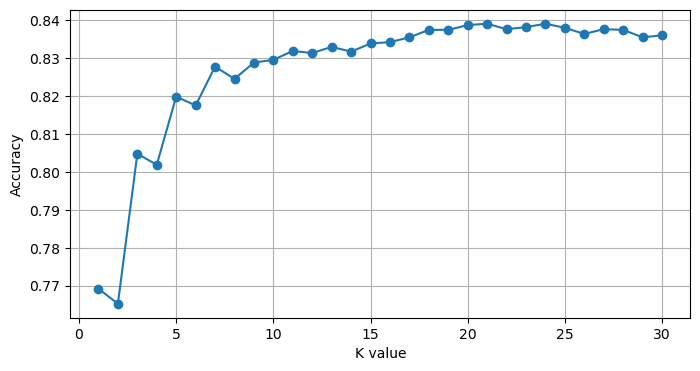

In [51]:
plt.figure(figsize=(8,4))
plt.plot(range(1,31),acc_list,marker='o')
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [52]:
# Initialize the kNN model
k = 24  # Number of neighbors
knn = KNeighborsClassifier(n_neighbors=k)

# Train the model
knn.fit(xtrain, ytrain)

KNeighborsClassifier(n_neighbors=24)

In [53]:
# Predict on the test set
ypred = knn.predict(xtest)

In [54]:
#To evaluate a model
from sklearn.metrics import accuracy_score          #this metrics used to check accuracy

In [55]:
accuracy_score(ypred,ytest)

0.8390165111270639

### Conclusion:
The K-Nearest Neighbors (KNN) algorithm was used to classify the dataset, achieving an initial accuracy of 83%. 
To enhance the model's performance, hyperparameter tuning was conducted using GridSearchCV. 
By selecting the optimal parameters (gs.best_params_), the accuracy improved to 83%. 
This demonstrates the importance of fine-tuning hyperparameters to achieve better classification results.

## 2. Logistic Regression :

In [48]:
#Building model
lr=LogisticRegression()
lr.fit(xtrain,ytrain)
ypred=lr.predict(xtest)

In [49]:
#Evaluate a model
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.84      0.79      0.82      2344
           1       0.86      0.89      0.87      3228

    accuracy                           0.85      5572
   macro avg       0.85      0.84      0.84      5572
weighted avg       0.85      0.85      0.85      5572



In [50]:
#Confusion Metrics
confusion_matrix(ytest,ypred)

array([[1858,  486],
       [ 352, 2876]], dtype=int64)

In [51]:
#Building model
lr=LogisticRegression(solver='liblinear')
lr.fit(xtrain,ytrain)
ypred=lr.predict(xtest)

print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.84      0.79      0.82      2344
           1       0.86      0.89      0.87      3228

    accuracy                           0.85      5572
   macro avg       0.85      0.84      0.84      5572
weighted avg       0.85      0.85      0.85      5572



In [52]:
lr=LogisticRegression(solver='newton-cg')
lr.fit(xtrain,ytrain)
ypred=lr.predict(xtest)

print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.84      0.79      0.82      2344
           1       0.86      0.89      0.87      3228

    accuracy                           0.85      5572
   macro avg       0.85      0.84      0.84      5572
weighted avg       0.85      0.85      0.85      5572



In [53]:
lr=LogisticRegression(solver='sag')
lr.fit(xtrain,ytrain)
ypred=lr.predict(xtest)

print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.84      0.79      0.82      2344
           1       0.86      0.89      0.87      3228

    accuracy                           0.85      5572
   macro avg       0.85      0.84      0.84      5572
weighted avg       0.85      0.85      0.85      5572



In [54]:
lr=LogisticRegression(solver='saga')
lr.fit(xtrain,ytrain)
ypred=lr.predict(xtest)

print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.84      0.79      0.82      2344
           1       0.86      0.89      0.87      3228

    accuracy                           0.85      5572
   macro avg       0.85      0.84      0.84      5572
weighted avg       0.85      0.85      0.85      5572



### Conclusion :
The logistic regression model achieved a consistent accuracy of 85% across different solvers (default, liblinear,newton-cg,
sag, and saga), indicating stable performance and robustness. 
    This suggests that the data is relatively simple, and the solver choice has minimal impact on accuracy.

## 3. Support Vector Machine (SVM)

In [57]:
svc=SVC()

def mymodel(m):
    m.fit(xtrain,ytrain)
    ypred=m.predict(xtest)
    print(classification_report(ytest,ypred))
    return m

In [56]:
mymodel(svc)

              precision    recall  f1-score   support

           0       0.84      0.78      0.81      2344
           1       0.85      0.89      0.87      3228

    accuracy                           0.85      5572
   macro avg       0.85      0.84      0.84      5572
weighted avg       0.85      0.85      0.85      5572



SVC()

In [57]:
p1=Pipeline(steps=[('scaling',StandardScaler()),('svm',SVC()),])

In [58]:
p1.fit(xtrain,ytrain)
ypred=p1.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.84      0.78      0.81      2344
           1       0.85      0.89      0.87      3228

    accuracy                           0.85      5572
   macro avg       0.85      0.84      0.84      5572
weighted avg       0.85      0.85      0.85      5572



### Hypertuning with kernel,c,gamma :

In [60]:
svc=SVC(kernel='linear')
mymodel(svc)

              precision    recall  f1-score   support

           0       0.85      0.79      0.82      2344
           1       0.86      0.89      0.87      3228

    accuracy                           0.85      5572
   macro avg       0.85      0.84      0.85      5572
weighted avg       0.85      0.85      0.85      5572



SVC(kernel='linear')

In [61]:
svc=SVC(kernel='sigmoid')
mymodel(svc)

              precision    recall  f1-score   support

           0       0.78      0.76      0.77      2344
           1       0.83      0.84      0.84      3228

    accuracy                           0.81      5572
   macro avg       0.80      0.80      0.80      5572
weighted avg       0.81      0.81      0.81      5572



SVC(kernel='sigmoid')

In [62]:
svc=SVC(kernel='poly')
mymodel(svc)

              precision    recall  f1-score   support

           0       0.85      0.77      0.81      2344
           1       0.85      0.90      0.87      3228

    accuracy                           0.85      5572
   macro avg       0.85      0.84      0.84      5572
weighted avg       0.85      0.85      0.85      5572



SVC(kernel='poly')

In [63]:
param_grid={'C':[1,10],'gamma':[1,10],'kernel':['rbf']}

In [64]:
gd=GridSearchCV(svc,param_grid,verbose=3)
#Verbose is not a hyperparameter.It is used just to display info
gd.fit(xtrain,ytrain)
ypred=gd.predict(xtest)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.810 total time= 1.6min
[CV 2/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.816 total time= 1.6min
[CV 3/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.802 total time= 1.6min
[CV 4/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.818 total time= 1.6min
[CV 5/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.812 total time= 1.6min
[CV 1/5] END .........C=1, gamma=10, kernel=rbf;, score=0.587 total time= 1.9min
[CV 2/5] END .........C=1, gamma=10, kernel=rbf;, score=0.588 total time= 1.9min
[CV 3/5] END .........C=1, gamma=10, kernel=rbf;, score=0.588 total time= 1.9min
[CV 4/5] END .........C=1, gamma=10, kernel=rbf;, score=0.588 total time= 1.9min
[CV 5/5] END .........C=1, gamma=10, kernel=rbf;, score=0.587 total time= 2.0min
[CV 1/5] END .........C=10, gamma=1, kernel=rbf;, score=0.806 total time= 1.7min
[CV 2/5] END .........C=10, gamma=1, kernel=rbf;,

In [65]:
gd.best_params_

{'C': 1, 'gamma': 1, 'kernel': 'rbf'}

In [66]:
svc=gd.best_estimator_
svc.fit(xtrain,ytrain)
ypred=svc.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.82      0.73      0.77      2344
           1       0.82      0.88      0.85      3228

    accuracy                           0.82      5572
   macro avg       0.82      0.80      0.81      5572
weighted avg       0.82      0.82      0.82      5572



### Conclusion:
The Support Vector Machine achieve the 85% accuracy.Again here done hypertune with kernel(linear,poly)for search better accuracy but kernel accuracy remains best.

## 4. Decision Tree 

In [67]:
dt=DecisionTreeClassifier()

In [68]:
mymodel(dt)

              precision    recall  f1-score   support

           0       0.72      0.73      0.73      2344
           1       0.81      0.80      0.80      3228

    accuracy                           0.77      5572
   macro avg       0.76      0.77      0.76      5572
weighted avg       0.77      0.77      0.77      5572



DecisionTreeClassifier()

In [69]:
#To check accuracy during training
dt.score(xtrain,ytrain)              #overfitting problem

1.0

### Hypertuning in DT (Pruning techniques)

In [70]:
for i in range(1,31):
    dt1=DecisionTreeClassifier(max_depth=i)
    dt1.fit(xtrain,ytrain)
    ypred=dt1.predict(xtest)
    ac=accuracy_score(ytest,ypred)
    print(f"Max Depth={i} Accuracy={ac}")

Max Depth=1 Accuracy=0.7810480976310122
Max Depth=2 Accuracy=0.7810480976310122
Max Depth=3 Accuracy=0.8241206030150754
Max Depth=4 Accuracy=0.8241206030150754
Max Depth=5 Accuracy=0.8259152907394114
Max Depth=6 Accuracy=0.8325556353194544
Max Depth=7 Accuracy=0.8365039483129936
Max Depth=8 Accuracy=0.83183776022972
Max Depth=9 Accuracy=0.832735104091888
Max Depth=10 Accuracy=0.8214285714285714
Max Depth=11 Accuracy=0.8194544149318018
Max Depth=12 Accuracy=0.8086862885857861
Max Depth=13 Accuracy=0.7982770997846375
Max Depth=14 Accuracy=0.7907394113424264
Max Depth=15 Accuracy=0.7779971284996411
Max Depth=16 Accuracy=0.7756640344580044
Max Depth=17 Accuracy=0.7745872218234028
Max Depth=18 Accuracy=0.7727925340990668
Max Depth=19 Accuracy=0.7718951902368988
Max Depth=20 Accuracy=0.7747666905958364
Max Depth=21 Accuracy=0.7731514716439339
Max Depth=22 Accuracy=0.7740488155061019
Max Depth=23 Accuracy=0.7731514716439339
Max Depth=24 Accuracy=0.7674084709260589
Max Depth=25 Accuracy=0.7729

In [71]:
dt2=DecisionTreeClassifier(max_depth=7)
mymodel(dt2)

              precision    recall  f1-score   support

           0       0.82      0.79      0.80      2344
           1       0.85      0.87      0.86      3228

    accuracy                           0.84      5572
   macro avg       0.83      0.83      0.83      5572
weighted avg       0.84      0.84      0.84      5572



DecisionTreeClassifier(max_depth=7)

In [72]:
dt2.score(xtrain,ytrain)

0.844303854264818

In [73]:
#Hypertuning with mean_samples_split
for i in range(2,51):
    dt1=DecisionTreeClassifier(min_samples_split=i)
    dt1.fit(xtrain,ytrain)
    ypred=dt1.predict(xtest)
    ac=accuracy_score(ytest,ypred)
    print(f"min samples split={i} Accuracy={ac}")

min samples split=2 Accuracy=0.7744077530509691
min samples split=3 Accuracy=0.7695620961952621
min samples split=4 Accuracy=0.7692031586503948
min samples split=5 Accuracy=0.7699210337401292
min samples split=6 Accuracy=0.7720746590093324
min samples split=7 Accuracy=0.7735104091888011
min samples split=8 Accuracy=0.7790739411342427
min samples split=9 Accuracy=0.7821249102656138
min samples split=10 Accuracy=0.7858937544867193
min samples split=11 Accuracy=0.7896625987078248
min samples split=12 Accuracy=0.7923546302943287
min samples split=13 Accuracy=0.797559224694903
min samples split=14 Accuracy=0.8024048815506102
min samples split=15 Accuracy=0.801148600143575
min samples split=16 Accuracy=0.8063531945441493
min samples split=17 Accuracy=0.8076094759511845
min samples split=18 Accuracy=0.8092246949030869
min samples split=19 Accuracy=0.8099425699928212
min samples split=20 Accuracy=0.8128140703517588
min samples split=21 Accuracy=0.8115577889447236
min samples split=22 Accuracy=

In [41]:
dt3=DecisionTreeClassifier(min_samples_split=50)
mymodel(dt3)

              precision    recall  f1-score   support

           0       0.80      0.78      0.79      2344
           1       0.85      0.86      0.85      3228

    accuracy                           0.83      5572
   macro avg       0.82      0.82      0.82      5572
weighted avg       0.83      0.83      0.83      5572



DecisionTreeClassifier(min_samples_split=50)

In [42]:
dt3.score(xtrain,ytrain)

0.8665589805716337

In [76]:
for i in range(1,51):
    dt1=DecisionTreeClassifier(min_samples_leaf=i)
    dt1.fit(xtrain,ytrain)
    ypred=dt1.predict(xtest)
    ac=accuracy_score(ytest,ypred)
    print(f"min samples split={i} Accuracy={ac}")

min samples split=1 Accuracy=0.7708183776022972
min samples split=2 Accuracy=0.7672290021536252
min samples split=3 Accuracy=0.7779971284996411
min samples split=4 Accuracy=0.7894831299353913
min samples split=5 Accuracy=0.7923546302943287
min samples split=6 Accuracy=0.8018664752333095
min samples split=7 Accuracy=0.8086862885857861
min samples split=8 Accuracy=0.8158650394831299
min samples split=9 Accuracy=0.8183776022972002
min samples split=10 Accuracy=0.8173007896625987
min samples split=11 Accuracy=0.8250179468772434
min samples split=12 Accuracy=0.8280689160086145
min samples split=13 Accuracy=0.8268126346015793
min samples split=14 Accuracy=0.824300071787509
min samples split=15 Accuracy=0.8262742282842785
min samples split=16 Accuracy=0.8250179468772434
min samples split=17 Accuracy=0.8277099784637473
min samples split=18 Accuracy=0.8295046661880833
min samples split=19 Accuracy=0.8296841349605169
min samples split=20 Accuracy=0.8320172290021536
min samples split=21 Accuracy=

In [77]:
dt4=DecisionTreeClassifier(min_samples_leaf=35)
mymodel(dt4)

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      2344
           1       0.85      0.87      0.86      3228

    accuracy                           0.84      5572
   macro avg       0.84      0.83      0.84      5572
weighted avg       0.84      0.84      0.84      5572



DecisionTreeClassifier(min_samples_leaf=35)

In [78]:
dt4.score(xtrain,ytrain)

0.8502714586978957

### Conclusion :
The Decision Tree model initially achieved an accuracy of 76% without hyperparameter tuning. After applying hyperparameter tuning, various parameters were adjusted to optimize the model performance:

max_depth resulted in an accuracy of 84%,

min_samples_split improved the accuracy to 83%, and

min_samples_leaf yielded an accuracy of 84%.
    
These improvements indicate that hyperparameter tuning significantly enhanced the model's performance, with max_depth & min_samples_leaf providing the best results. Therefore, tuning these parameters helps improve the model's ability to generalize and achieve better predictive accuracy.

## 5. Ensemble Learning

### 1.1)Bagging

In [79]:
bg=BaggingClassifier(LogisticRegression())
bg.fit(xtrain,ytrain)
ypred=bg.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.84      0.79      0.82      2344
           1       0.86      0.89      0.87      3228

    accuracy                           0.85      5572
   macro avg       0.85      0.84      0.84      5572
weighted avg       0.85      0.85      0.85      5572



In [80]:
bg=BaggingClassifier(KNeighborsClassifier())
bg.fit(xtrain,ytrain)
ypred=bg.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.80      0.76      0.78      2344
           1       0.83      0.86      0.85      3228

    accuracy                           0.82      5572
   macro avg       0.82      0.81      0.81      5572
weighted avg       0.82      0.82      0.82      5572



In [81]:
bg=BaggingClassifier(SVC())
bg.fit(xtrain,ytrain)
ypred=bg.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.84      0.79      0.81      2344
           1       0.85      0.89      0.87      3228

    accuracy                           0.85      5572
   macro avg       0.85      0.84      0.84      5572
weighted avg       0.85      0.85      0.85      5572



In [82]:
bg=BaggingClassifier(DecisionTreeClassifier())
bg.fit(xtrain,ytrain)
ypred=bg.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.78      0.81      0.79      2344
           1       0.86      0.83      0.84      3228

    accuracy                           0.82      5572
   macro avg       0.82      0.82      0.82      5572
weighted avg       0.82      0.82      0.82      5572



### Random Forest :

In [83]:
rf=RandomForestClassifier()
rf.fit(xtrain,ytrain)
ypred=rf.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.83      0.79      0.81      2344
           1       0.85      0.88      0.87      3228

    accuracy                           0.84      5572
   macro avg       0.84      0.84      0.84      5572
weighted avg       0.84      0.84      0.84      5572



### Conclusion :
By applying Bagging from Ensemble Learning, the **Logistic Regression Classifier & SVM** outperforms other models with the best accuracy of **85%**. This result highlights the effectiveness of ensemble methods in improving model performance. Bagging helps in reducing variance and overfitting, and in this case, the Logistic Regression Classifier benefits from this technique, delivering a more robust and reliable prediction compared to other classifiers tested.

### 1.2) Voting

In [84]:
models=[]
acc=[]
models.append(("LogisticReg",LogisticRegression()))
models.append(("Dec Tree",DecisionTreeClassifier()))
models.append(("knn",KNeighborsClassifier()))
models.append(("svm",SVC()))

In [85]:
vc=VotingClassifier(estimators=models)
vc.fit(xtrain,ytrain)
ypred=vc.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.82      0.81      0.82      2344
           1       0.87      0.87      0.87      3228

    accuracy                           0.84      5572
   macro avg       0.84      0.84      0.84      5572
weighted avg       0.84      0.84      0.84      5572



### Conclusion :
The Voting Classifier combines multiple models (Logistic Regression, Decision Tree, K-Nearest Neighbors, and SVM) and achieves 84% accuracy. 

### 2) Boosting

In [86]:
ada=AdaBoostClassifier()
ada.fit(xtrain,ytrain)
ypred=ada.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.84      0.79      0.81      2344
           1       0.86      0.89      0.87      3228

    accuracy                           0.85      5572
   macro avg       0.85      0.84      0.84      5572
weighted avg       0.85      0.85      0.85      5572



In [87]:
gd=GradientBoostingClassifier()
gd.fit(xtrain,ytrain)
ypred=gd.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.84      0.80      0.82      2344
           1       0.86      0.89      0.87      3228

    accuracy                           0.85      5572
   macro avg       0.85      0.84      0.85      5572
weighted avg       0.85      0.85      0.85      5572



In [88]:
xgb=XGBClassifier()
xgb.fit(xtrain,ytrain)
ypred=xgb.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.82      0.79      0.81      2344
           1       0.85      0.88      0.86      3228

    accuracy                           0.84      5572
   macro avg       0.84      0.83      0.84      5572
weighted avg       0.84      0.84      0.84      5572



### Conclusion :

- **AdaBoost** achieved an accuracy of **85%**, showing strong performance with better precision and recall for class 1.
- **Gradient Boosting** also gave an accuracy of **85%**, performing similarly to AdaBoost with balanced precision and recall.
- **XGBoost** achieved an accuracy of **84%**, slightly lower than the other two but still a competitive result.

In summary, **AdaBoost** & **Gradient Boosting** provides the best performance among the boosting algorithms tested.

## 6. Naive Bay's

In [89]:
mymodel(GaussianNB())

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2344
           1       0.58      1.00      0.73      3228

    accuracy                           0.58      5572
   macro avg       0.29      0.50      0.37      5572
weighted avg       0.34      0.58      0.42      5572



GaussianNB()

In [91]:
mymodel(BernoulliNB())

              precision    recall  f1-score   support

           0       0.80      0.76      0.78      2344
           1       0.83      0.87      0.85      3228

    accuracy                           0.82      5572
   macro avg       0.82      0.81      0.82      5572
weighted avg       0.82      0.82      0.82      5572



BernoulliNB()

### Conclusion
The **Bernoulli Naïve Bayes model** achieved **82% accuracy**, indicating it effectively predicts student depression based on the given features. 

### Final Conclusion :
The **highest accuracy of 85%** was achieved using **Logistic Regression, SVC (Linear & Polynomial), Bagging (Logistic & SVC), and Boosting (AdaBoost & XGBoost)**, indicating that these models are the most effective for predicting student depression. Based on performance, **Boosting techniques (AdaBoost & XGBoost) are recommended** for their ability to handle complex patterns and improve predictive accuracy. 

### **How Does This Benefit the End User?**  
This project benefits different groups of people:  
1. **Students** – They get awareness about their mental health and access to early help.  
2. **Teachers & Schools** – Schools can identify struggling students and provide support.  
3. **Parents** – Parents can understand the challenges their children face.  
4. **Counselors & Psychologists** – They get data-driven insights to offer better mental health guidance.  

#### **Who is the End User?**  
The **end users** of this project include:  
- **Students** (who are the main focus)  
- **Teachers & School Administrators**  
- **Parents & Guardians**  
- **Mental Health Professionals**  
- **Government & Educational Policymakers**  